# Приоритизация обращений

**Цель:** ранжировать обращения внутри каждого дня по вероятности успешного действия в следующие 5 дней
**Метрика:** Daily Average Precision


Содержание ноутбука:

1. EDA и аудит возможной утечки
2. точная реализация Daily AP
3. expanding-window валидация по будущим датам
4. безопасные признаки из `events.csv`
5. ablation и обоснованный выбор модели
6. финальный ансамбль CatBoost и `submission.csv`

Используются только локальные open-source библиотеки. Внешние API, LLM, ручная разметка test и правила по конкретным `lead_id` отсутствуют.

## 0. Установка и переносимые пути

Для воспроизводимости ноутбука добавил несколько вариантов путей к файлам (сам работал на kaggle):

1. путь из переменной окружения `LEAD_CHALLENGE_DIR`;
2. подключённый Kaggle Dataset `/kaggle/input/datasets/mihailivanovvvv/avito-entry-test/lead_prioritization_challenge`;
3. стандартная локальная структура архива рядом с ноутбуком: `data/train.csv`, `data/test.csv`, `data/events.csv` и `sample_submission.csv`;
4. подпапка `lead_prioritization_challenge` в текущем или родительском каталоге.

На Kaggle результаты сохраняются в `/kaggle/working`. При локальном запуске — в `./outputs`. При необходимости входной и выходной каталоги можно задать переменными `LEAD_CHALLENGE_DIR` и `LEAD_OUTPUT_DIR`. Поэтому менять код перед передачей проверяющему не требуется.


In [17]:
from __future__ import annotations

import gc
import os
import re
import warnings
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp
from sklearn.metrics import average_precision_score, roc_auc_score

try:
    from catboost import CatBoostClassifier
except ImportError as exc:
    raise ImportError("Установите CatBoost: pip install catboost==1.2.8") from exc

warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
plt.style.use("seaborn-v0_8-whitegrid")


In [18]:
REQUIRED_FILES = (
    Path("data/train.csv"),
    Path("data/test.csv"),
    Path("data/events.csv"),
    Path("sample_submission.csv"),
)


def is_dataset_root(path: Path) -> bool:
    return path.is_dir() and all((path / relative_path).is_file() for relative_path in REQUIRED_FILES)


def resolve_input_dir() -> Path:
    candidates = []
    environment_path = os.getenv("LEAD_CHALLENGE_DIR")
    if environment_path:
        candidates.append(Path(environment_path).expanduser())

    kaggle_path = Path(
        "/kaggle/input/datasets/mihailivanovvvv/avito-entry-test/"
        "lead_prioritization_challenge"
    )
    current = Path.cwd()
    candidates.extend(
        [
            kaggle_path,
            current,
            current / "lead_prioritization_challenge",
            current.parent / "lead_prioritization_challenge",
            current / "challenge_data" / "lead_prioritization_challenge",
        ]
    )

    checked = []
    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate in checked:
            continue
        checked.append(candidate)
        if is_dataset_root(candidate):
            return candidate

    checked_text = "\n".join(f"  - {path}" for path in checked)
    raise FileNotFoundError(
        "Не найден корень датасета. Проверены пути:\n"
        f"{checked_text}\n"
        "Укажите корректный путь через переменную окружения LEAD_CHALLENGE_DIR."
    )


def resolve_output_dir() -> Path:
    environment_path = os.getenv("LEAD_OUTPUT_DIR")
    if environment_path:
        return Path(environment_path).expanduser().resolve()
    kaggle_working = Path("/kaggle/working")
    if kaggle_working.is_dir():
        return kaggle_working
    return Path.cwd() / "outputs"


@dataclass(frozen=True)
class Config:
    input_dir: Path
    output_dir: Path
    target: str = "target"
    id_col: str = "lead_id"
    user_col: str = "user_id"
    date_col: str = "assignment_date"
    ts_col: str = "assignment_ts"
    seed: int = 42
    final_seeds: tuple[int, ...] = (42, 2026)
    cv_folds: int = 3
    valid_days: int = 3
    iterations: int = 1200
    learning_rate: float = 0.03
    depth: int = 6
    early_stopping_rounds: int = 140
    thread_count: int = 4
    run_cv: bool = True


CFG = Config(input_dir=resolve_input_dir(), output_dir=resolve_output_dir())
CFG.output_dir.mkdir(parents=True, exist_ok=True)
np.random.seed(CFG.seed)

TRAIN_PATH = CFG.input_dir / "data" / "train.csv"
TEST_PATH = CFG.input_dir / "data" / "test.csv"
EVENTS_PATH = CFG.input_dir / "data" / "events.csv"
SAMPLE_PATH = CFG.input_dir / "sample_submission.csv"

print("Каталог данных:", CFG.input_dir)
print("Каталог результатов:", CFG.output_dir)


Каталог данных: /kaggle/input/datasets/mihailivanovvvv/avito-entry-test/lead_prioritization_challenge
Каталог результатов: /kaggle/working


# Часть I. EDA и аудит данных

EDA здесь отвечает на конкретные вопросы:

- соответствует ли временная валидация скрытому test;
- можно ли использовать идентификаторы;
- как выражены дисбаланс и пропуски;
- какие raw-признаки имеют устойчивый сигнал;
- насколько train и test различаются;
- какая доля событий находится в будущем и должна быть удалена.


In [19]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
events = pd.read_csv(EVENTS_PATH)
sample_submission = pd.read_csv(SAMPLE_PATH)

train[CFG.ts_col] = pd.to_datetime(train[CFG.ts_col], errors="raise")
test[CFG.ts_col] = pd.to_datetime(test[CFG.ts_col], errors="raise")
train[CFG.date_col] = pd.to_datetime(train[CFG.date_col], errors="raise")
test[CFG.date_col] = pd.to_datetime(test[CFG.date_col], errors="raise")
events["event_ts"] = pd.to_datetime(events["event_ts"], errors="raise")

assert train[CFG.id_col].is_unique and test[CFG.id_col].is_unique
assert CFG.target not in test.columns
assert set(train[CFG.target].dropna().unique()) <= {0, 1}
assert set(train.columns) - {CFG.target} == set(test.columns)
assert list(sample_submission.columns) == [CFG.id_col, "score"]

summary = pd.DataFrame(
    {
        "dataset": ["train", "test", "events"],
        "rows": [len(train), len(test), len(events)],
        "columns": [train.shape[1], test.shape[1], events.shape[1]],
    }
)
display(summary)
print("Target mean:", train[CFG.target].mean())
print("Train dates:", train[CFG.date_col].min().date(), "—", train[CFG.date_col].max().date())
print("Test dates:", test[CFG.date_col].min().date(), "—", test[CFG.date_col].max().date())


,dataset,rows,columns
0,train,13694,119
1,test,4306,118
2,events,254705,7


Target mean: 0.20746312253541696
Train dates: 2026-04-07 — 2026-04-22
Test dates: 2026-04-23 — 2026-04-27


### 1. Время, размер дневных групп и target

Важно проверить, что target не испытывает резкого тренда и что дни имеют сопоставимый размер.


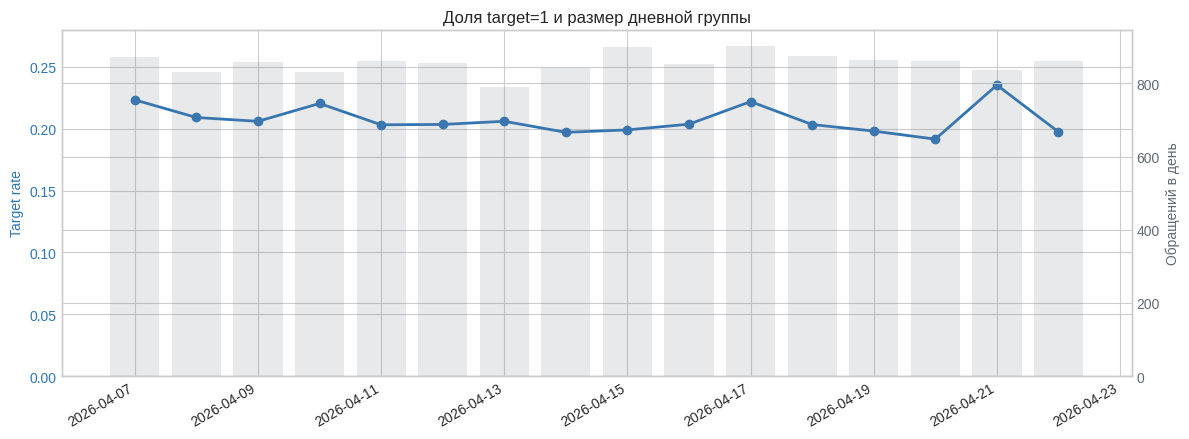

,target_rate,positives,rows
assignment_date,,,
2026-04-07,0.2234,195,873
2026-04-08,0.2091,174,832
2026-04-09,0.2061,177,859
2026-04-10,0.2205,183,830
2026-04-11,0.2033,175,861
2026-04-12,0.2035,174,855
2026-04-13,0.2061,163,791
2026-04-14,0.1971,166,842
2026-04-15,0.1991,179,899


In [20]:
daily = train.groupby(CFG.date_col)[CFG.target].agg(target_rate="mean", positives="sum", rows="size")

fig, ax1 = plt.subplots(figsize=(12, 4.5))
ax1.plot(daily.index, daily["target_rate"], marker="o", color="#2E74B5", linewidth=2)
ax1.set_ylabel("Target rate", color="#2E74B5")
ax1.tick_params(axis="y", labelcolor="#2E74B5")
ax1.set_ylim(0, max(0.28, daily["target_rate"].max() * 1.15))
ax2 = ax1.twinx()
ax2.bar(daily.index, daily["rows"], alpha=0.18, color="#7A8793")
ax2.set_ylabel("Обращений в день", color="#606A73")
ax2.tick_params(axis="y", labelcolor="#606A73")
ax1.set_title("Доля target=1 и размер дневной группы")
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

display(daily.round(4))


### 2. Идентификаторы и категории

`lead_id` и `user_id` проверяются как потенциальные источники запоминания. Если ID уникален и не повторяется в test, модель не сможет переносить по нему закономерность.


,column,train_unique,test_unique,train_test_overlap
0,lead_id,13694,4306,0
1,user_id,13694,4306,0


,feature,train_unique,test_unseen,missing_train
0,lead_source,3,0,0.0
1,call_center,2,0,0.0
2,region,5,0,0.0
3,car_segment,4,0,0.0
4,lead_channel,4,0,0.0
5,user_tenure_bucket,3,0,0.0
6,price_bucket,3,0,0.0


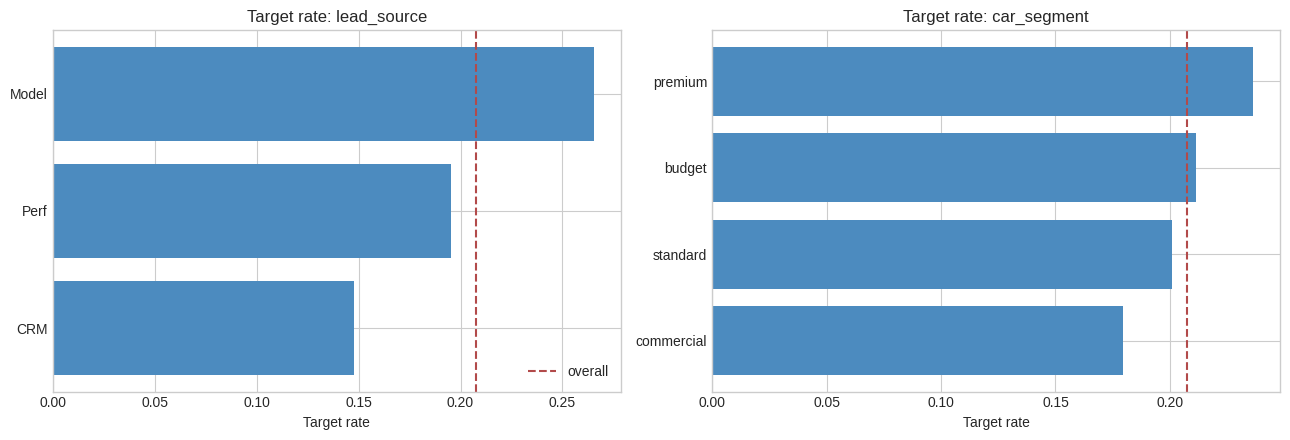

In [21]:
id_audit = pd.DataFrame(
    {
        "column": [CFG.id_col, CFG.user_col],
        "train_unique": [train[CFG.id_col].nunique(), train[CFG.user_col].nunique()],
        "test_unique": [test[CFG.id_col].nunique(), test[CFG.user_col].nunique()],
        "train_test_overlap": [
            len(set(train[CFG.id_col]) & set(test[CFG.id_col])),
            len(set(train[CFG.user_col]) & set(test[CFG.user_col])),
        ],
    }
)
display(id_audit)

categorical_columns_raw = [
    c for c in test.columns
    if pd.api.types.is_string_dtype(test[c]) and c not in {CFG.id_col, CFG.user_col}
]
category_audit = []
for column in categorical_columns_raw:
    category_audit.append(
        {
            "feature": column,
            "train_unique": train[column].nunique(dropna=True),
            "test_unseen": len(set(test[column].dropna().astype(str)) - set(train[column].dropna().astype(str))),
            "missing_train": train[column].isna().mean(),
        }
    )
display(pd.DataFrame(category_audit))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, column in zip(axes, ["lead_source", "car_segment"]):
    rates = train.groupby(column)[CFG.target].agg(["mean", "size"]).sort_values("mean")
    ax.barh(rates.index.astype(str), rates["mean"], color="#4C8BBF")
    ax.axvline(train[CFG.target].mean(), color="#B24A4A", linestyle="--", label="overall")
    ax.set_title(f"Target rate: {column}")
    ax.set_xlabel("Target rate")
axes[0].legend()
plt.tight_layout()
plt.show()


**Вывод:** оба ID уникальны и не пересекаются между train/test, поэтому оба исключаются из модели. `lead_id` сохраняется только для submission. Содержательные категории CatBoost сможет обработать без one-hot encoding'а


### 3. Пропуски и train-test shift

CatBoost нативно работает с числовыми NaN. Для EDA я проверил масштаб пропусков и поискал сильный сдвиг распределений между train и test.


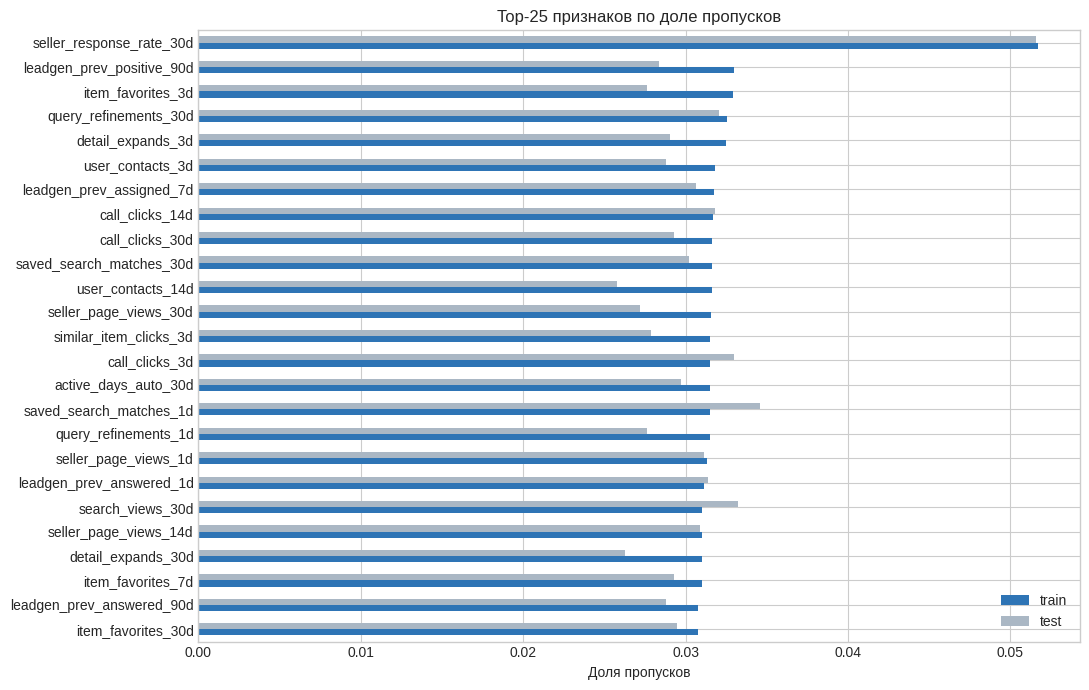

,feature,KS,train_missing,test_missing
1,assignment_weekday,0.2935,0.0000,0.0000
2,is_weekend,0.1324,0.0000,0.0000
9,car_age_years,0.0347,0.0000,0.0000
39,seller_page_views_30d,0.0205,0.0315,0.0272
52,query_refinements_90d,0.0192,0.0298,0.0276
28,detail_expands_90d,0.0184,0.0287,0.0283
75,chat_opens_30d,0.0181,0.0294,0.0293
6,seller_inventory_count,0.0176,0.0000,0.0000
4,user_age_days,0.0175,0.0000,0.0000
105,active_days_auto_30d,0.0167,0.0315,0.0297


In [22]:
missing = pd.DataFrame(
    {"train": train.drop(columns=CFG.target).isna().mean(), "test": test.isna().mean()}
).sort_values("train", ascending=False)
missing_nonzero = missing[missing.max(axis=1) > 0]

top_missing = missing_nonzero.head(25).sort_values("train")
top_missing.plot(kind="barh", figsize=(11, 7), color=["#2E74B5", "#AAB7C4"])
plt.title("Top-25 признаков по доле пропусков")
plt.xlabel("Доля пропусков")
plt.tight_layout()
plt.show()

numeric_columns_raw = [c for c in test.columns if pd.api.types.is_numeric_dtype(test[c])]
shift_rows = []
for column in numeric_columns_raw:
    train_values = train[column].dropna()
    test_values = test[column].dropna()
    if len(train_values) and len(test_values):
        shift_rows.append(
            {
                "feature": column,
                "KS": ks_2samp(train_values, test_values).statistic,
                "train_missing": train[column].isna().mean(),
                "test_missing": test[column].isna().mean(),
            }
        )
shift = pd.DataFrame(shift_rows).sort_values("KS", ascending=False)
display(shift.head(20).round(4))


### 4. Одномерный сигнал raw-признаков

Одномерный AUC — диагностический инструмент, который показывает, какие семейства признаков заслуживают большего внимания. Знак AUC разворачивается, поэтому отображается `max(AUC, 1−AUC)`.


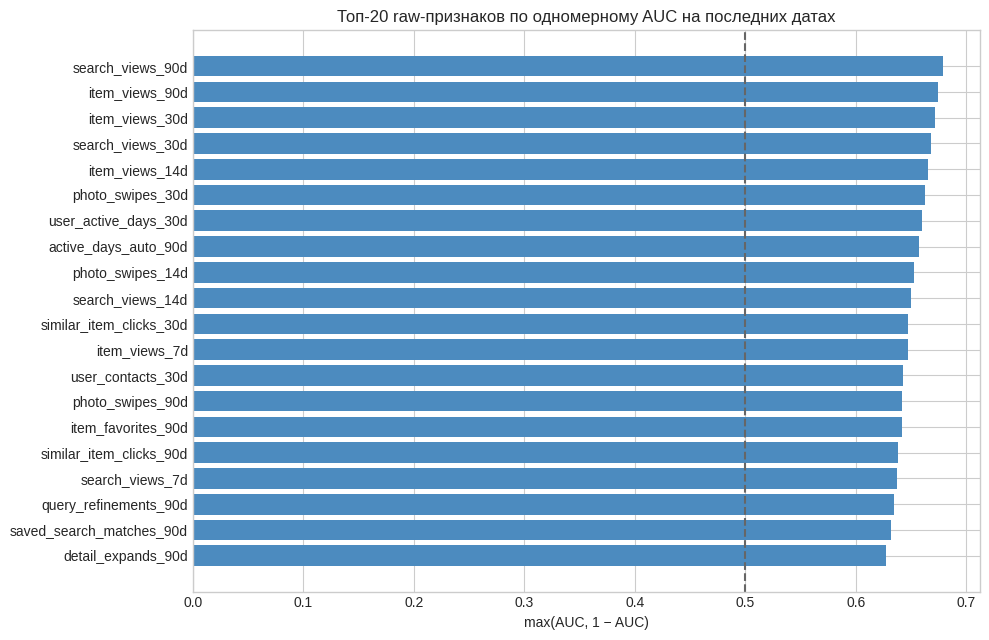

,feature,direction_free_auc
46,search_views_90d,0.6784
16,item_views_90d,0.6740
15,item_views_30d,0.6717
45,search_views_30d,0.6680
14,item_views_14d,0.6654
33,photo_swipes_30d,0.6621
3,user_active_days_30d,0.6598
106,active_days_auto_90d,0.6572
32,photo_swipes_14d,0.6522
44,search_views_14d,0.6497


In [24]:
latest_dates = sorted(train[CFG.date_col].unique())[-4:]
valid_mask_eda = train[CFG.date_col].isin(latest_dates)
univariate_rows = []
for column in numeric_columns_raw:
    median = train.loc[~valid_mask_eda, column].median()
    values = train.loc[valid_mask_eda, column].fillna(median)
    if values.nunique() < 2:
        continue
    auc = roc_auc_score(train.loc[valid_mask_eda, CFG.target], values)
    univariate_rows.append({"feature": column, "direction_free_auc": max(auc, 1 - auc)})

univariate = pd.DataFrame(univariate_rows).sort_values("direction_free_auc", ascending=False)
top = univariate.head(20).sort_values("direction_free_auc")
plt.figure(figsize=(10, 6.5))
plt.barh(top["feature"], top["direction_free_auc"], color="#4C8BBF")
plt.axvline(0.5, color="#666666", linestyle="--")
plt.title("Топ-20 raw-признаков по одномерному AUC на последних датах")
plt.xlabel("max(AUC, 1 − AUC)")
plt.tight_layout()
plt.show()
display(univariate.head(25).round(4))


### 5. Аудит events.csv и границы leakage

События сначала связываются с назначением, затем сравниваются по времени. Признаки разрешено строить **только** после фильтра `event_ts < assignment_ts`.


,share
timing,
до назначения,0.936651
после назначения,0.063302
нет события,0.000047


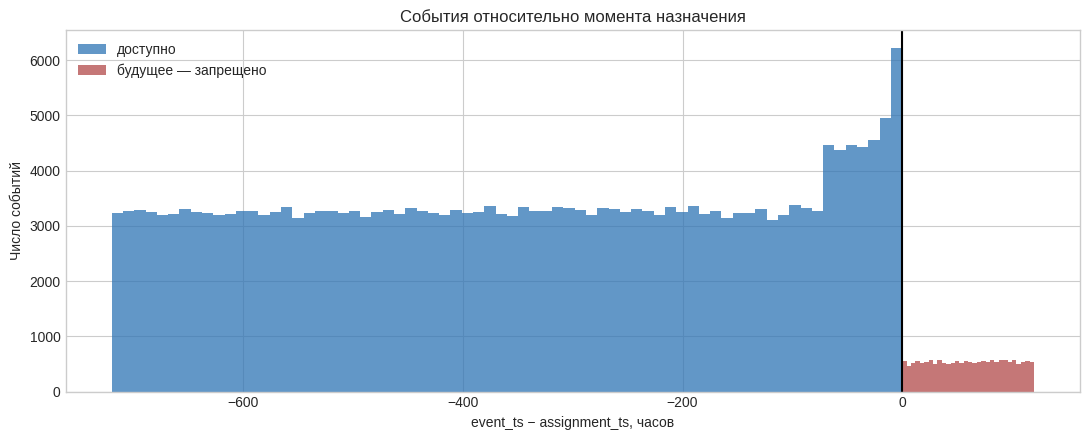

In [25]:
assignment_keys = pd.concat(
    [
        train[[CFG.id_col, CFG.ts_col]].assign(split="train"),
        test[[CFG.id_col, CFG.ts_col]].assign(split="test"),
    ],
    ignore_index=True,
)
event_audit = assignment_keys.merge(events, on=CFG.id_col, how="left")
event_audit["delta_hours"] = (
    event_audit["event_ts"] - event_audit[CFG.ts_col]
).dt.total_seconds() / 3600
event_audit["timing"] = np.select(
    [event_audit["delta_hours"] < 0, event_audit["delta_hours"] >= 0],
    ["до назначения", "после назначения"],
    default="нет события",
)

timing_summary = event_audit["timing"].value_counts(normalize=True).rename("share").to_frame()
display(timing_summary)

plt.figure(figsize=(11, 4.5))
plt.hist(event_audit.loc[event_audit.delta_hours < 0, "delta_hours"], bins=70, alpha=0.75, label="доступно", color="#2E74B5")
plt.hist(event_audit.loc[event_audit.delta_hours >= 0, "delta_hours"], bins=30, alpha=0.75, label="будущее — запрещено", color="#B24A4A")
plt.axvline(0, color="black", linewidth=1.5)
plt.xlabel("event_ts − assignment_ts, часов")
plt.ylabel("Число событий")
plt.title("События относительно момента назначения")
plt.legend()
plt.tight_layout()
plt.show()


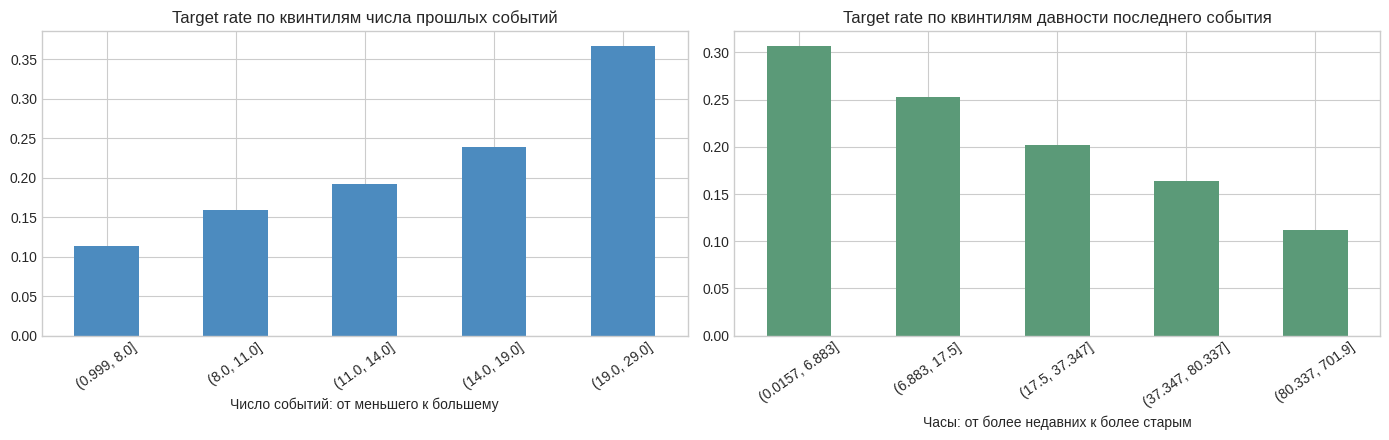

,ctx_seq,leads,target_rate_if_present
2,c03,255,1.0000
6,c07,693,0.6061
4,c05,650,0.5785
7,c08,10925,0.2231
5,c06,12079,0.2163
1,c02,12340,0.2161
0,c01,12597,0.2152
3,c04,12128,0.2150


In [26]:
# Только безопасная часть train-events для диагностических графиков.
safe_train_events = (
    train[[CFG.id_col, CFG.ts_col, CFG.target]]
    .merge(events, on=CFG.id_col, how="left")
)
safe_train_events = safe_train_events[
    safe_train_events["event_ts"].notna()
    & (safe_train_events["event_ts"] < safe_train_events[CFG.ts_col])
].copy()
safe_train_events["age_hours"] = (
    safe_train_events[CFG.ts_col] - safe_train_events["event_ts"]
).dt.total_seconds() / 3600

lead_event_summary = safe_train_events.groupby(CFG.id_col).agg(
    events_total=("event_ts", "size"),
    last_event_age_hours=("age_hours", "min"),
    target=(CFG.target, "first"),
)
lead_event_summary["count_bin"] = pd.qcut(lead_event_summary["events_total"], 5, duplicates="drop")
lead_event_summary["recency_bin"] = pd.qcut(lead_event_summary["last_event_age_hours"], 5, duplicates="drop")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
lead_event_summary.groupby("count_bin", observed=True)["target"].mean().plot(kind="bar", ax=axes[0], color="#4C8BBF")
axes[0].set_title("Target rate по квинтилям числа прошлых событий")
axes[0].set_xlabel("Число событий: от меньшего к большему")
lead_event_summary.groupby("recency_bin", observed=True)["target"].mean().plot(kind="bar", ax=axes[1], color="#5B9A78")
axes[1].set_title("Target rate по квинтилям давности последнего события")
axes[1].set_xlabel("Часы: от более недавних к более старым")
for ax in axes:
    ax.tick_params(axis="x", labelrotation=35)
plt.tight_layout()
plt.show()

ctx_presence = pd.crosstab(safe_train_events[CFG.id_col], safe_train_events["ctx_seq"])
ctx_target = train.set_index(CFG.id_col)[CFG.target]
ctx_rows = []
for column in ctx_presence.columns:
    present_ids = ctx_presence.index[ctx_presence[column] > 0]
    ctx_rows.append(
        {
            "ctx_seq": column,
            "leads": len(present_ids),
            "target_rate_if_present": ctx_target.loc[present_ids].mean(),
        }
    )
display(pd.DataFrame(ctx_rows).sort_values("target_rate_if_present", ascending=False).round(4))


## Выводы EDA

1. Train — короткий временной отрезок, test идёт сразу после него => нужна expanding-window CV по целым дням.
2. `lead_id` и `user_id` уникальны и не переносятся в test => оба исключаются.
3. Содержательные категории низкокардинальны; CatBoost подходит лучше one-hot pipeline.
4. Основной raw-сигнал находится в длинных окнах просмотров, поиска и активности.
5. Безопасные число/давность событий, последний тип, `ctx_seq`, `src_slot` и расхождение исторической цены дают сильный сигнал.
6. Сильный `ctx_seq` используется как универсальная категория, а не как ручное правило для отдельных значений.


# Часть II. Метрика и временная валидация

Для каждого дня обращения сортируются по убыванию score. AP усредняет Precision@k на позициях положительных объектов.


In [28]:
def daily_average_precision(y_true, y_score, dates, return_by_day=False):
    metric_df = pd.DataFrame(
        {
            "target": np.asarray(y_true),
            "score": np.asarray(y_score, dtype=float),
            "date": pd.to_datetime(pd.Series(dates)).dt.date.to_numpy(),
        }
    )
    rows = []
    for day, part in metric_df.groupby("date", sort=True):
        positives = int(part["target"].sum())
        ap = 0.0 if positives == 0 else average_precision_score(part["target"], part["score"])
        rows.append({"date": day, "ap": float(ap), "rows": len(part), "positives": positives})
    by_day = pd.DataFrame(rows)
    value = float(by_day["ap"].mean())
    return (value, by_day) if return_by_day else value


assert np.isclose(
    daily_average_precision([1, 0, 1], [0.9, 0.8, 0.7], ["2026-01-01"] * 3),
    (1 + 2 / 3) / 2,
)


### Почему основная CV без purge

В выданном train всего 16 дат, все `lead_id` и `user_id` уникальны, а признаки строятся point-in-time. Пятидневный purge удалил бы почти половину доступного обучения и отвечал бы на другой вопрос: «какие метки уже созрели прямо утром валидации». Все train-метки явно предоставлены как доступная история.

Поэтому основная оценка — три expanding-window split по три будущих дня. Для production переобучение всё равно должно учитывать пятидневную задержку появления меток.


In [29]:
def make_expanding_date_folds(df, n_folds=CFG.cv_folds, valid_days=CFG.valid_days):
    dates = np.array(sorted(pd.to_datetime(df[CFG.date_col]).dt.normalize().unique()))
    first_valid_pos = len(dates) - n_folds * valid_days
    if first_valid_pos < 2:
        raise ValueError("Недостаточно уникальных дат для выбранной схемы CV")
    folds = []
    row_dates = pd.to_datetime(df[CFG.date_col]).dt.normalize()
    for fold in range(n_folds):
        start = first_valid_pos + fold * valid_days
        valid_dates = dates[start : start + valid_days]
        train_idx = np.flatnonzero(row_dates < valid_dates[0])
        valid_idx = np.flatnonzero(row_dates.isin(valid_dates))
        folds.append((train_idx, valid_idx, valid_dates))
    return folds


folds = make_expanding_date_folds(train)
for fold_number, (fit_idx, valid_idx, valid_dates) in enumerate(folds, 1):
    print(
        fold_number,
        "train rows:", len(fit_idx),
        "validation:", pd.Timestamp(valid_dates[0]).date(), "—", pd.Timestamp(valid_dates[-1]).date(),
        "valid rows:", len(valid_idx),
    )


1 train rows: 5901 validation: 2026-04-14 — 2026-04-16 valid rows: 2595
2 train rows: 8496 validation: 2026-04-17 — 2026-04-19 valid rows: 2639
3 train rows: 11135 validation: 2026-04-20 — 2026-04-22 valid rows: 2559


# Часть III. Feature engineering

EDA показал, что исходная таблица уже содержит сильные оконные агрегаты, а массовое добавление сотен ratios ухудшает временной holdout. Поэтому табличная часть останется компактной: исходные признаки плюс циклическое кодирование часа и дня недели. Главный прирост дают корректные event-признаки.


In [30]:
def build_tabular_features(df):
    x = df.drop(columns=[CFG.target], errors="ignore").copy()
    assignment_ts = pd.to_datetime(x[CFG.ts_col], errors="coerce")
    hour = pd.to_numeric(x["assignment_hour"], errors="coerce")
    weekday = pd.to_numeric(x["assignment_weekday"], errors="coerce")

    x["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    x["hour_cos"] = np.cos(2 * np.pi * hour / 24)
    x["weekday_sin"] = np.sin(2 * np.pi * weekday / 7)
    x["weekday_cos"] = np.cos(2 * np.pi * weekday / 7)
    x["minutes_since_day_start"] = assignment_ts.dt.hour * 60 + assignment_ts.dt.minute

    return x.drop(columns=[CFG.id_col, CFG.user_col, CFG.ts_col, CFG.date_col], errors="ignore")


In [31]:
def build_event_features(assignments, events_df):
    keys = assignments[[CFG.id_col, CFG.ts_col, "item_price_log"]].copy()
    keys["_row_id"] = np.arange(len(keys), dtype=np.int64)
    keys["_assignment_ts"] = pd.to_datetime(keys[CFG.ts_col], errors="coerce")
    keys["_assignment_price"] = pd.to_numeric(keys["item_price_log"], errors="coerce")

    e = events_df.copy()
    e["event_ts"] = pd.to_datetime(e["event_ts"], errors="coerce")
    merged = keys[["_row_id", CFG.id_col, "_assignment_ts", "_assignment_price"]].merge(
        e, on=CFG.id_col, how="left"
    )

    # Главный anti-leakage барьер. Он выполняется ДО любой агрегации.
    merged = merged[
        merged["event_ts"].notna()
        & (merged["event_ts"] < merged["_assignment_ts"])
    ].copy()
    assert (merged["event_ts"] < merged["_assignment_ts"]).all()

    merged["age_hours"] = (
        merged["_assignment_ts"] - merged["event_ts"]
    ).dt.total_seconds() / 3600
    merged["event_day"] = merged["event_ts"].dt.floor("D")
    merged["event_price"] = pd.to_numeric(merged["item_price_log"], errors="coerce")
    merged["price_abs_diff"] = (merged["event_price"] - merged["_assignment_price"]).abs()
    merged = merged.sort_values(["_row_id", "event_ts"])

    result = pd.DataFrame({"_row_id": keys["_row_id"]})
    grouped = merged.groupby("_row_id", sort=False)
    basic = grouped.agg(
        events_total=("event_ts", "size"),
        event_types_nunique=("event_type", "nunique"),
        event_active_days=("event_day", "nunique"),
        event_src_slot_nunique=("src_slot", "nunique"),
        event_ctx_nunique=("ctx_seq", "nunique"),
        event_age_h_min=("age_hours", "min"),
        event_age_h_mean=("age_hours", "mean"),
        event_age_h_std=("age_hours", "std"),
        event_age_h_max=("age_hours", "max"),
        event_price_diff_mean=("price_abs_diff", "mean"),
        event_price_diff_min=("price_abs_diff", "min"),
        event_price_diff_max=("price_abs_diff", "max"),
        event_price_diff_last=("price_abs_diff", "last"),
        last_event_type=("event_type", "last"),
        last_event_ctx=("ctx_seq", "last"),
        last_event_src_slot=("src_slot", "last"),
    ).reset_index()
    result = result.merge(basic, on="_row_id", how="left")

    merged["gap_hours"] = grouped["event_ts"].diff().dt.total_seconds() / 3600
    gaps = grouped["gap_hours"].agg(["mean", "std", "min", "max"])
    gaps.columns = [f"event_gap_h_{stat}" for stat in gaps.columns]
    result = result.merge(gaps, left_on="_row_id", right_index=True, how="left")

    for hours in (1, 3, 6, 12, 24, 72, 168, 720):
        counts = (
            merged.loc[merged["age_hours"] <= hours]
            .groupby("_row_id")
            .size()
            .rename(f"events_count_{hours}h")
        )
        result = result.merge(counts, left_on="_row_id", right_index=True, how="left")

    # Универсальные counts категорий; никаких ручных правил для c03/c05/...
    for category, prefix in [("event_type", "event_type"), ("ctx_seq", "event_ctx")]:
        totals = pd.crosstab(merged["_row_id"], merged[category].fillna("__MISSING__"))
        totals.columns = [f"{prefix}_count__{c}" for c in totals.columns]
        result = result.merge(totals, left_on="_row_id", right_index=True, how="left")

        for hours in (6, 24, 72, 168):
            recent_part = merged.loc[merged["age_hours"] <= hours]
            recent = pd.crosstab(recent_part["_row_id"], recent_part[category].fillna("__MISSING__"))
            recent.columns = [f"{prefix}_count_{hours}h__{c}" for c in recent.columns]
            result = result.merge(recent, left_on="_row_id", right_index=True, how="left")

    for event_type in sorted(merged["event_type"].dropna().unique()):
        recency = (
            merged.loc[merged["event_type"] == event_type]
            .groupby("_row_id")["age_hours"]
            .min()
            .rename(f"event_recency_h__{event_type}")
        )
        result = result.merge(recency, left_on="_row_id", right_index=True, how="left")

    count_prefixes = ("events_count", "event_type_count", "event_ctx_count")
    for column in [c for c in result.columns if c.startswith(count_prefixes)]:
        result[column] = result[column].fillna(0)
    result["events_missing"] = result["events_total"].isna().astype("int8")
    return result.drop(columns="_row_id")


In [32]:
X_train_tabular = build_tabular_features(train)
X_test_tabular = build_tabular_features(test)

X_train_events = build_event_features(train.drop(columns=CFG.target), events)
X_test_events = build_event_features(test, events)
X_test_events = X_test_events.reindex(columns=X_train_events.columns, fill_value=0)

X_train = pd.concat([X_train_tabular.reset_index(drop=True), X_train_events.reset_index(drop=True)], axis=1)
X_test = pd.concat([X_test_tabular.reset_index(drop=True), X_test_events.reset_index(drop=True)], axis=1)
y = train[CFG.target].astype(int).reset_index(drop=True)

assert list(X_train.columns) == list(X_test.columns)
assert CFG.target not in X_train and CFG.id_col not in X_train and CFG.user_col not in X_train
print("Feature matrices:", X_train.shape, X_test.shape)


Feature matrices: (13694, 218) (4306, 218)


### Категориальные признаки

CatBoost использует ordered target statistics и хеширование категорий. Числовые NaN он обрабатывает нативно. Строковые пропуски заменяются отдельным токеном; новые значения test допустимы и не требуют ручного target encoding'а.


In [33]:
def detect_categorical_columns(frame):
    explicit = {
        "lead_source", "call_center", "region", "car_segment", "lead_channel",
        "user_tenure_bucket", "price_bucket", "assignment_weekday", "is_weekend",
        "last_event_type", "last_event_ctx", "last_event_src_slot",
    }
    return [
        c for c in frame.columns
        if c in explicit or frame[c].dtype == "object" or isinstance(frame[c].dtype, pd.StringDtype)
    ]


def prepare_categorical_frames(train_frame, other_frame, categorical_columns):
    train_ready = train_frame.copy()
    other_ready = other_frame.copy()
    for column in categorical_columns:
        train_ready[column] = train_ready[column].astype("string").fillna("__MISSING__").astype(str)
        other_ready[column] = other_ready[column].astype("string").fillna("__MISSING__").astype(str)
    return train_ready, other_ready


categorical_columns = detect_categorical_columns(X_train)
print("Categorical features:", categorical_columns)


Categorical features: ['lead_source', 'call_center', 'region', 'car_segment', 'lead_channel', 'user_tenure_bucket', 'price_bucket', 'assignment_weekday', 'is_weekend', 'last_event_type', 'last_event_ctx', 'last_event_src_slot']


# Часть IV. Модель, CV и ablation

Проверенные варианты на последнем временном holdout:

| Вариант | Daily AP |
|---|---:|
| CatBoost, только исходная таблица | ≈ 0.538 |
| Сотни автоматически созданных ratios, без events | ≈ 0.524 |
| Компактная таблица + безопасные events | ≈ 0.711–0.716 |
| Та же модель без `ctx_seq` | ≈ 0.649 |
| YetiRank MAP | ≈ 0.558 |

Ранкер и его blend ухудшили результат, поэтому финальная модель — классификатор. Это не противоречит ранжированию, ведь Daily AP использует порядок вероятностей, а не порог классификации.


In [34]:
def make_model(seed, iterations=CFG.iterations, verbose=False):
    return CatBoostClassifier(
        iterations=iterations,
        learning_rate=CFG.learning_rate,
        depth=CFG.depth,
        l2_leaf_reg=7.0,
        loss_function="Logloss",
        eval_metric="PRAUC:type=Classic",
        random_seed=seed,
        random_strength=0.5,
        bootstrap_type="Bayesian",
        bagging_temperature=0.7,
        allow_writing_files=False,
        verbose=verbose,
        thread_count=CFG.thread_count,
        task_type="CPU",
    )


In [35]:
cv_rows = []
oof_scores = np.full(len(train), np.nan)

if CFG.run_cv:
    for fold_number, (fit_idx, valid_idx, valid_dates) in enumerate(folds, 1):
        X_fit, X_valid = prepare_categorical_frames(
            X_train.iloc[fit_idx].reset_index(drop=True),
            X_train.iloc[valid_idx].reset_index(drop=True),
            categorical_columns,
        )
        model = make_model(CFG.seed)
        model.fit(
            X_fit,
            y.iloc[fit_idx],
            cat_features=categorical_columns,
            eval_set=(X_valid, y.iloc[valid_idx]),
            early_stopping_rounds=CFG.early_stopping_rounds,
            use_best_model=True,
        )
        prediction = model.predict_proba(X_valid)[:, 1]
        oof_scores[valid_idx] = prediction
        fold_daily_ap, by_day = daily_average_precision(
            y.iloc[valid_idx], prediction, train[CFG.date_col].iloc[valid_idx], return_by_day=True
        )
        cv_rows.append(
            {
                "fold": fold_number,
                "valid_start": pd.Timestamp(valid_dates[0]).date(),
                "valid_end": pd.Timestamp(valid_dates[-1]).date(),
                "train_rows": len(fit_idx),
                "valid_rows": len(valid_idx),
                "AP": average_precision_score(y.iloc[valid_idx], prediction),
                "Daily_AP": fold_daily_ap,
                "best_iteration": model.get_best_iteration(),
            }
        )
        print(cv_rows[-1])

cv_results = pd.DataFrame(cv_rows)
display(cv_results)
if not cv_results.empty:
    print("Mean Daily AP:", cv_results["Daily_AP"].mean())
    print("Std Daily AP:", cv_results["Daily_AP"].std(ddof=1))
    cv_results.to_csv(CFG.output_dir / "rolling_cv_results.csv", index=False)


{'fold': 1, 'valid_start': datetime.date(2026, 4, 14), 'valid_end': datetime.date(2026, 4, 16), 'train_rows': 5901, 'valid_rows': 2595, 'AP': np.float64(0.6690289215907351), 'Daily_AP': 0.6711053050865735, 'best_iteration': 630}
{'fold': 2, 'valid_start': datetime.date(2026, 4, 17), 'valid_end': datetime.date(2026, 4, 19), 'train_rows': 8496, 'valid_rows': 2639, 'AP': np.float64(0.7217253334329325), 'Daily_AP': 0.7220865675664907, 'best_iteration': 1103}
{'fold': 3, 'valid_start': datetime.date(2026, 4, 20), 'valid_end': datetime.date(2026, 4, 22), 'train_rows': 11135, 'valid_rows': 2559, 'AP': np.float64(0.7005985011050991), 'Daily_AP': 0.7039886318971709, 'best_iteration': 1199}


,fold,valid_start,valid_end,train_rows,valid_rows,AP,Daily_AP,best_iteration
0,1,2026-04-14,2026-04-16,5901,2595,0.669029,0.671105,630
1,2,2026-04-17,2026-04-19,8496,2639,0.721725,0.722087,1103
2,3,2026-04-20,2026-04-22,11135,2559,0.700599,0.703989,1199


Mean Daily AP: 0.6990601681834118
Std Daily AP: 0.025845494712714124


# Часть V. Финальное обучение и submission

Два разных сида дают немного разные ансамбли деревьев, поэтому я возьму их среднее, чтобы уменьшить дисперсию.


In [37]:
X_full, X_submit = prepare_categorical_frames(X_train, X_test, categorical_columns)
test_predictions = []
final_models = []
feature_importances = []

for seed in CFG.final_seeds:
    final_model = make_model(seed, verbose=200)
    final_model.fit(X_full, y, cat_features=categorical_columns)
    test_predictions.append(final_model.predict_proba(X_submit)[:, 1])
    feature_importances.append(final_model.get_feature_importance())
    final_model.save_model(str(CFG.output_dir / f"catboost_classifier_seed{seed}.cbm"))
    final_models.append(final_model)

final_score = np.mean(test_predictions, axis=0)
final_score = np.clip(final_score, 0.0, 1.0)


0:	learn: 0.5476176	total: 33.3ms	remaining: 39.9s
200:	learn: 0.7195080	total: 6.54s	remaining: 32.5s
400:	learn: 0.7867291	total: 13s	remaining: 26s
600:	learn: 0.8386054	total: 19.6s	remaining: 19.5s
800:	learn: 0.8796185	total: 26.2s	remaining: 13.1s
1000:	learn: 0.9118631	total: 32.8s	remaining: 6.52s
1199:	learn: 0.9372832	total: 39.2s	remaining: 0us
0:	learn: 0.5599878	total: 31.9ms	remaining: 38.2s
200:	learn: 0.7224113	total: 6.49s	remaining: 32.2s
400:	learn: 0.7875082	total: 13s	remaining: 26s
600:	learn: 0.8388578	total: 19.5s	remaining: 19.4s
800:	learn: 0.8794780	total: 26s	remaining: 13s
1000:	learn: 0.9114181	total: 32.5s	remaining: 6.46s
1199:	learn: 0.9373686	total: 39s	remaining: 0us


In [38]:
submission = pd.DataFrame(
    {
        CFG.id_col: test[CFG.id_col].astype(str),
        "score": final_score.astype(float),
    }
)

assert list(submission.columns) == [CFG.id_col, "score"]
assert len(submission) == len(test) == len(sample_submission)
assert submission[CFG.id_col].is_unique
assert submission["score"].notna().all()
assert np.isfinite(submission["score"]).all()
assert submission["score"].between(0, 1).all()
assert set(submission[CFG.id_col]) == set(sample_submission[CFG.id_col].astype(str))

submission_path = CFG.output_dir / "submission.csv"
submission.to_csv(submission_path, index=False)
print("Готово:", submission_path.resolve())
display(submission.head())


Готово: /kaggle/working/submission.csv


,lead_id,score
0,lead_97e409eb8f8c8246,0.042311
1,lead_55310edb4489f9e9,0.230096
2,lead_e7f653a2c6a7eee8,0.861644
3,lead_22f8e1cfc487ac20,0.054777
4,lead_48b638b839abfac3,0.145571


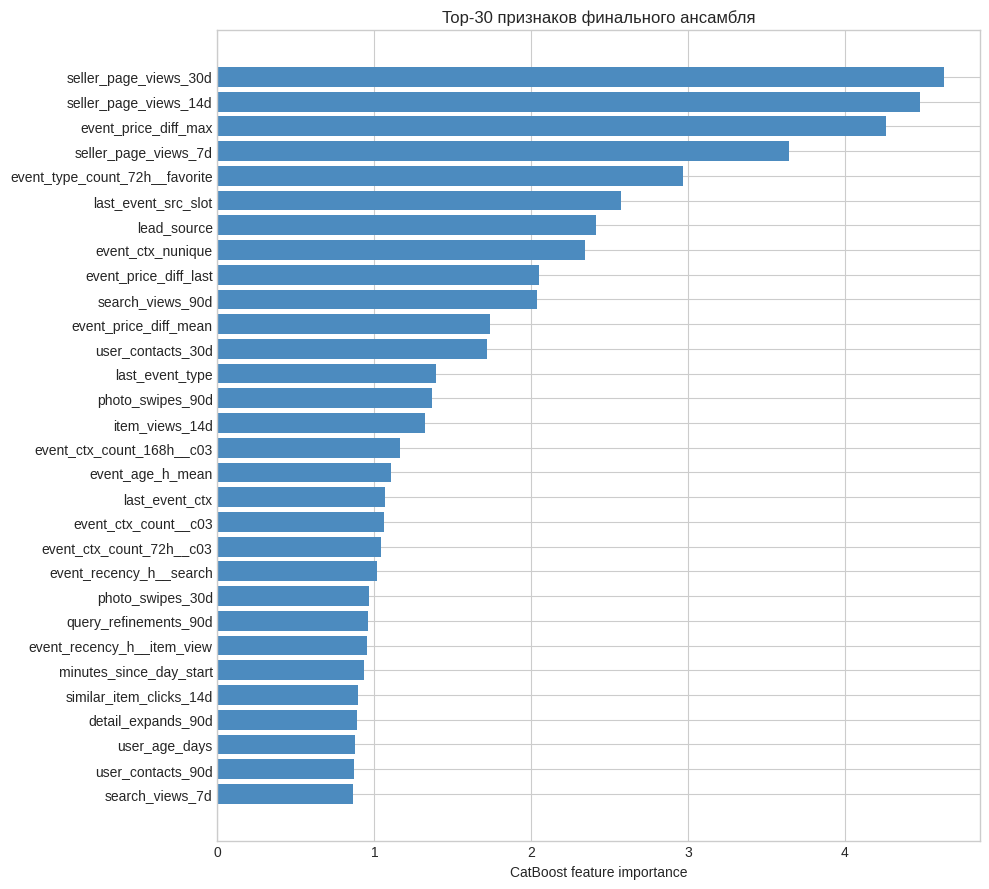

,feature,importance
46,seller_page_views_30d,4.629658
45,seller_page_views_14d,4.481688
130,event_price_diff_max,4.259913
44,seller_page_views_7d,3.646526
164,event_type_count_72h__favorite,2.965120
134,last_event_src_slot,2.574375
0,lead_source,2.410886
123,event_ctx_nunique,2.345092
131,event_price_diff_last,2.047188
53,search_views_90d,2.036507


In [39]:
importance = pd.DataFrame(
    {
        "feature": X_full.columns,
        "importance": np.mean(feature_importances, axis=0),
    }
).sort_values("importance", ascending=False)
importance.to_csv(CFG.output_dir / "feature_importance.csv", index=False)

top = importance.head(30).sort_values("importance")
plt.figure(figsize=(10, 9))
plt.barh(top["feature"], top["importance"], color="#4C8BBF")
plt.title("Top-30 признаков финального ансамбля")
plt.xlabel("CatBoost feature importance")
plt.tight_layout()
plt.show()
display(importance.head(30))


## Короткое описание решения для сдачи

Провёл EDA временной структуры, target, пропусков, категорий, train-test shift и дополнительных событий. `lead_id` и `user_id` исключены: оба уникальны и не пересекаются между train/test. Для оценки использована expanding-window CV по трём последовательным блокам будущих дат.

Модель использует исходные табличные признаки, циклические признаки времени и агрегаты из `events.csv`. События фильтруются условием `event_ts < assignment_ts` до любой агрегации. Строятся counts по временным окнам, давность и интервалы событий, counts типов и `ctx_seq`, последний тип/контекст/слот и статистики расхождения исторической цены с ценой назначения.

Основная модель — CatBoostClassifier. На временном holdout безопасные events повысили Daily AP примерно с 0.538 до 0.711–0.716; expanding-window CV дала средний Daily AP около 0.699. Избыточный автоматический feature engineering, class weighting и CatBoostRanker не улучшили validation и исключены. Финальный score — среднее вероятностей двух CatBoost с seed 42 и 2026. Используются только локальные open-source библиотеки pandas, NumPy, SciPy, scikit-learn, Matplotlib и CatBoost.
